In [24]:
from PIL import  Image
from matplotlib import  pyplot as plt

In [ ]:
img1 = Image.open('./charts/top_features.png')
img2  = Image.open('./charts/attrition vs monthlyincome.png')
img3 = Image.open('./charts/attrition vs job role.png')

### Rank the top 10 most important features driving employee exit.

## Q1 Which 3 factors most strongly predict that an employee will leave ?

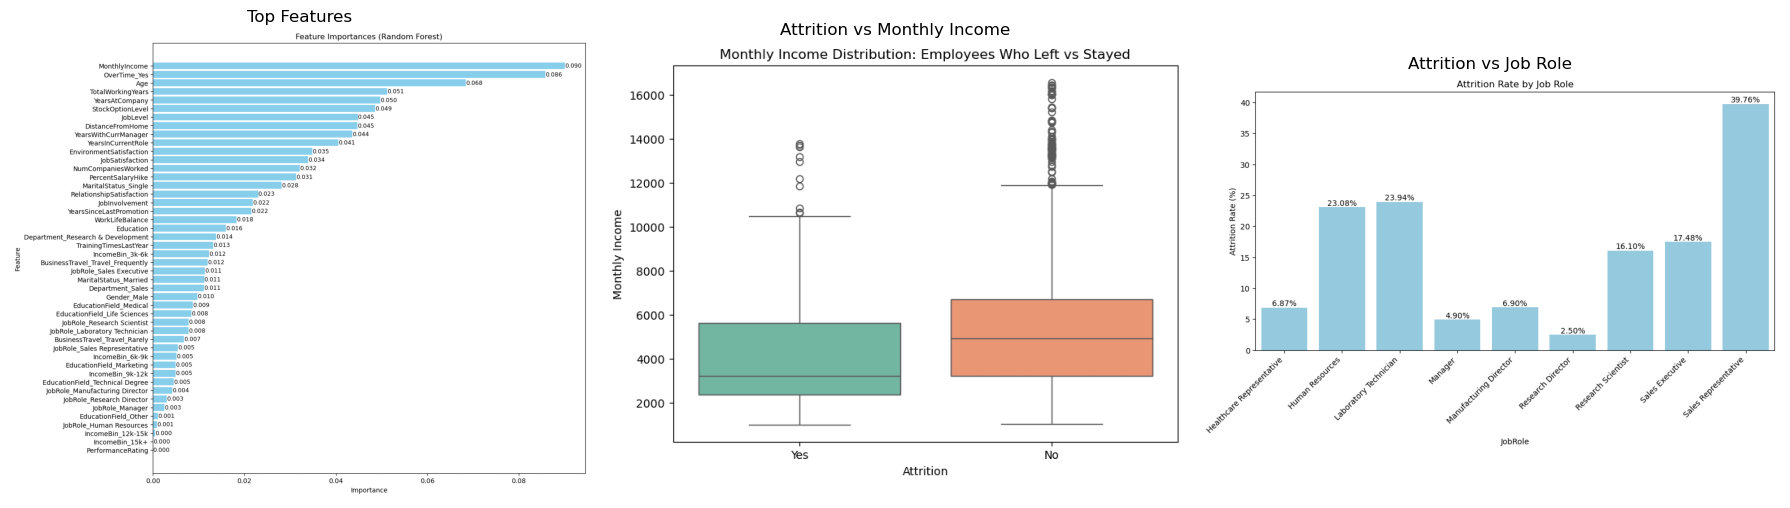

In [ ]:
titles = ["Top Features", "Attrition vs Monthly Income", "Attrition vs Job Role"]
graphs = [img1, img2, img3]

# Subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, img, title in zip(axes, graphs, titles):
    ax.imshow(img)
    ax.axis('off')          # hide axes
    ax.set_title(title)     # add subplot title

plt.tight_layout()
plt.show()

### Top 3 Factors of Employee Attrition

1. **Monthly Income**
- Employees with **lower income** are significantly more likely to leave.
- The boxplot shows a lower median income for the “Yes” group (leavers).
- Random Forest feature importance ranked Monthly Income as the 1 driver.

2. **OverTime(Yes)**
- Employees who work **overtime** face a much higher risk of attrition.
- “OverTime_Yes” is the **second most** influential feature in the Random Forest model.
- Indicates poor work‑life balance as a key factor in leaving.

3. **Age**
- Younger employees tend to leave more often.
- Age ranked third in feature importance.
- Matches job role insights: younger frontline roles (Sales Representatives, Lab Technicians) show the highest attrition.

## Q2 Which department or job role should HR prioritize for retention efforts?

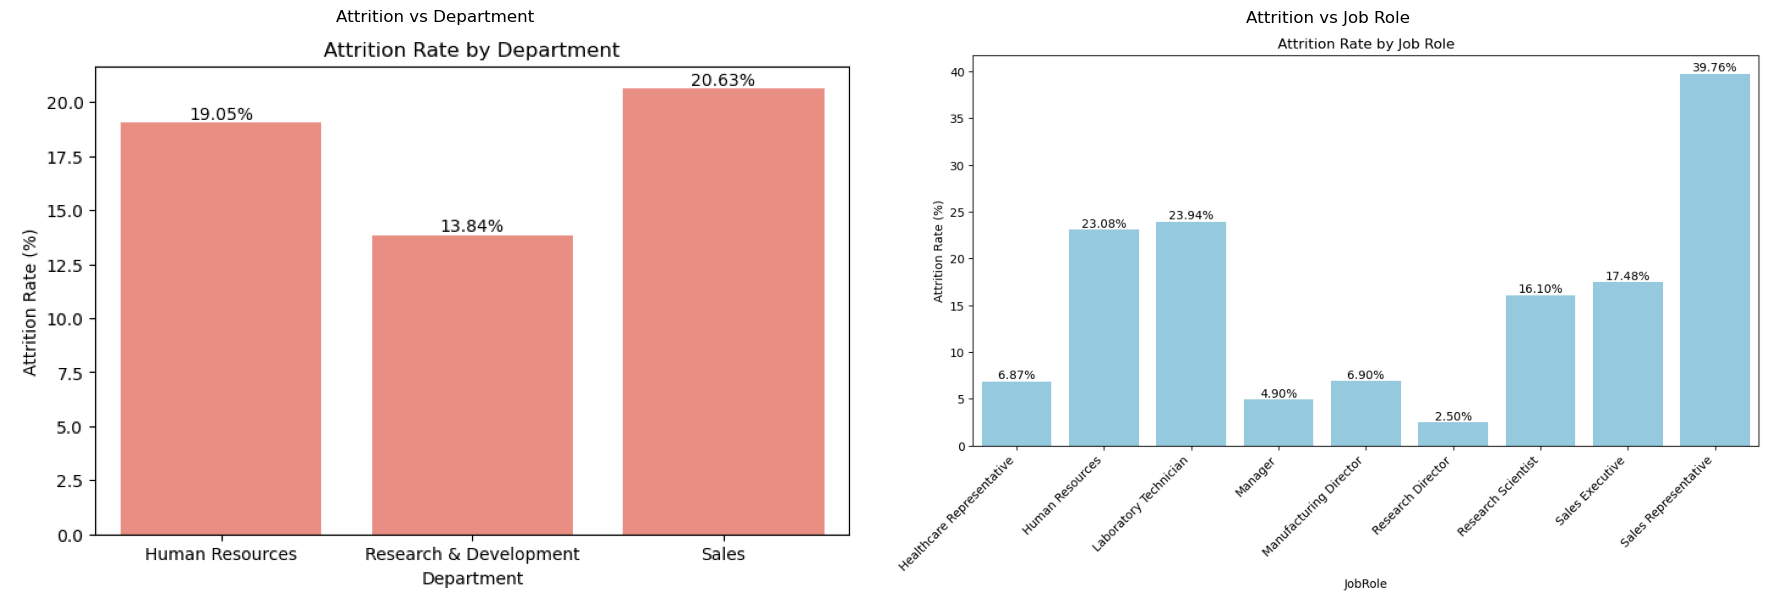

In [ ]:
img1 = Image.open('./charts/attrition vs Department.png')
img2 = Image.open('./charts/attrition vs job role.png')

titles = ["Attrition vs Department", "Attrition vs Job Role"]
graphs = [img1, img2]

# Subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18,6))

for ax, img, title in zip(axes, graphs, titles):
    ax.imshow(img)
    ax.axis('off')          # hide axes
    ax.set_title(title)     # add subplot title

plt.tight_layout()
plt.show()


### Evidence from the Analysis

1. Department-Level
- Sales Department has the highest attrition rate (20.63%).
- HR is also high (19.05%), but Sales is consistently the most vulnerable.
- R&D is relatively stable (13.84%).

2. Job Role-Level
- Sales Representatives face the highest attrition (39.76%) across all roles.
- Laboratory Technicians (~24%) and HR roles (~23%) also show elevated attrition.
- Managers and Research Directors are very stable (<5%).

3. Feature Importance
- Attrition is driven by low income, overtime, and younger age — all of which are common in frontline roles like Sales Representatives and Lab Technicians.


## Recommendation
HR should focus retention strategies on **Sales Representatives** first, followed by **Lab Technicians** and **HR staff**. These groups combine high attrition rates with key **risk factors (lower pay, overtime, younger workforce)**.

- Retention efforts could include:
- Compensation adjustments for lower-income roles.
- Work-life balance initiatives to reduce overtime stress.
- Career development programs targeting younger employees to improve engagement.

## Q3 Does salary alone explain attrition or are there other stronger factors?

Salary is indeed a strong predictor of attrition, but it does not fully explain why employees leave. The analysis shows that while lower monthly income is associated with higher attrition, other factors play an equally important or even stronger role. Employees working overtime are far more likely to leave, suggesting that work‑life balance pressures are a critical driver. Age also matters, with younger employees showing higher attrition rates, especially in frontline roles such as Sales Representatives and Lab Technicians. Department and job role patterns reinforce this: attrition is concentrated in Sales and HR, where lower pay, overtime demands, and younger workforce demographics overlap. In short, attrition is best explained by a combination of **low income, overtime workload, and younger age**, rather than salary alone.

## Q4 Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation).

1. Targeted Retention Program for Sales Representatives
- **Policy Change** : Introduce a structured retention initiative specifically for Sales Representatives, who face the highest attrition (~40%).
- **Action** : Conduct one‑on‑one retention conversations with Sales Representatives to understand pain points, then roll out targeted measures such as performance‑linked bonuses, career progression pathways, and flexible scheduling.
- **Goal** : Reduce turnover in the most vulnerable role by addressing both compensation and career development needs.

2. Work‑Life Balance Policy to Reduce Overtime
- **Policy Change** : Implement stricter overtime monitoring and introduce a “Right to Disconnect” policy that limits after‑hours work.
- **Action** : HR should identify employees consistently logging overtime and proactively schedule retention conversations with them. Offer alternatives such as workload redistribution, wellness programs, or compensatory time off.
- **Goal** : Lower attrition risk among employees experiencing burnout, especially younger staff in frontline roles.

## Rank the top 10 most important features driving employee exit.

<img src='./charts/top_features.png' />

<br/>

- Monthly Income → 9.0%
- OverTime (Yes) → 8.6%
- Age → 6.8%
- Total Working Years → 5.1%
- Years at Company → 5.0%
- Stock Option Level → 4.9%
- Years in Current Role → 4.1%
- Years with Current Manager → 4.0%
- Job Role: Sales Representative → 3.9%
- Job Role: Laboratory Technician → 3.4%

Insight
- Monthly Income, OverTime, and Age together account for ~24% of the predictive power, making them the strongest signals.
- Tenure‑related features (Years at Company, Years in Current Role, Years with Current Manager) collectively add another ~13%.
- Specific job roles like Sales Representatives and Lab Technicians contribute ~7% combined, highlighting role‑based vulnerability.

## BEST MODEL : Logistic Regression (Why ?)

<img src='./charts/comparisions.png' />

### Model Performance Comparison

| Metric | Logistic Regression | Random Forest | XGBoost |
|----------|----------:|----------:|----------:|
| Accuracy | 73.47% | 80.61% | 80.61% |
| Precision | 35.0% | **42.2%** | 41.9% |
| Recall | **76.6%** | 57.4% | 55.3% |
| F1 Score | 48.0% | **48.6%** | 47.7% |
| ROC-AUC | **0.747** | 0.712 | 0.704 |
| Overfitting | Low | Moderate | High |
| Interpretability | High | Medium | Low |

---

### Confusion Matrix Analysis

#### Logistic Regression

| Actual \ Predicted | No Attrition (0) | Attrition (1) |
|-------------------|------------------|---------------|
| No Attrition (0) | 180 | 67 |
| Attrition (1) | 11 | 36 |

#### Metrics

- True Negatives (TN): 180
- False Positives (FP): 67
- False Negatives (FN): 11
- True Positives (TP): 36

#### Interpretation

Logistic Regression correctly identified **36 out of 47 employees who left the company**, achieving the highest recall among all models. Although it generated more false positives, it missed the fewest attrition cases.

---

## Random Forest

| Actual \ Predicted | No Attrition (0) | Attrition (1) |
|-------------------|------------------|---------------|
| No Attrition (0) | 210 | 37 |
| Attrition (1) | 20 | 27 |

### Metrics

- True Negatives (TN): 210
- False Positives (FP): 37
- False Negatives (FN): 20
- True Positives (TP): 27

### Interpretation

Random Forest achieved higher precision and accuracy than Logistic Regression but failed to identify as many attrition cases, resulting in lower recall.

---

## XGBoost

| Actual \ Predicted | No Attrition (0) | Attrition (1) |
|-------------------|------------------|---------------|
| No Attrition (0) | 211 | 36 |
| Attrition (1) | 21 | 26 |

### Metrics

- True Negatives (TN): 211
- False Positives (FP): 36
- False Negatives (FN): 21
- True Positives (TP): 26

### Interpretation

XGBoost produced performance similar to Random Forest but detected fewer attrition cases and exhibited signs of overfitting.

---

# Confusion Matrix Summary

| Metric | Logistic Regression | Random Forest | XGBoost |
|----------|----------:|----------:|----------:|
| True Negatives (TN) | 180 | 210 | 211 |
| False Positives (FP) | 67 | 37 | 36 |
| False Negatives (FN) | **11** | 20 | 21 |
| True Positives (TP) | **36** | 27 | 26 |
| Attrition Cases Identified | **36 / 47** | 27 / 47 | 26 / 47 |

---


#### 1. Highest ROC-AUC Score

Logistic Regression achieved the highest ROC-AUC score (**0.747**) among all evaluated models.

| Model | ROC-AUC |
|---------|---------|
| Logistic Regression | **0.747** |
| Random Forest | 0.712 |
| XGBoost | 0.704 |

A higher ROC-AUC indicates better ability to distinguish between employees who leave and employees who stay.

---

#### 2. Highest Recall

Recall is a critical metric in employee attrition prediction because the objective is to identify employees at risk of leaving.

| Model | Recall |
|---------|---------|
| Logistic Regression | **76.6%** |
| Random Forest | 57.4% |
| XGBoost | 55.3% |

Logistic Regression correctly identified:

- **36 out of 47 attrition cases**

This means HR teams would receive more early warnings about employees likely to resign.

---

#### 3. Better Generalization

| Model | Train AUC | Test AUC |
|---------|---------|---------|
| Logistic Regression | ~0.756 | 0.747 |
| XGBoost | ~0.946 | 0.704 |

The small gap between training and testing performance indicates that Logistic Regression generalizes well to unseen data.

The larger gap observed in XGBoost suggests overfitting.

---

#### 4. Suitable for Small Structured Datasets

Dataset Characteristics:

- Total Records: 1,470
- Features: 18
- Binary Classification Problem
- Class Imbalance: 84% No Attrition, 16% Attrition

For datasets of this size, relationships between predictors and attrition are often approximately linear. Logistic Regression effectively captures these relationships while avoiding excessive model complexity.

Examples:

- Overtime increases attrition risk.
- Job Satisfaction decreases attrition risk.
- Monthly Income decreases attrition risk.
- Years at Company decreases attrition risk.

---

#### 5. Reduced Overfitting

Tree-based models such as Random Forest and XGBoost are capable of learning highly complex patterns.

However, with a relatively small dataset, these models may learn noise from the training data.

XGBoost Results:

| Metric | Value |
|----------|---------|
| Training AUC | 0.946 |
| Testing AUC | 0.704 |

This performance gap indicates overfitting.

Logistic Regression avoids this issue because of its simpler structure and built-in regularization.

---

#### Business Impact Analysis

The primary objective of an attrition prediction system is to identify employees who are likely to leave the organization.

| Model | Employees Missed (FN) |
|---------|---------:|
| Logistic Regression | **11** |
| Random Forest | 20 |
| XGBoost | 21 |

Logistic Regression missed the fewest employees who actually left the company.

This enables HR teams to:

- Identify at-risk employees earlier.
- Improve employee retention strategies.
- Reduce recruitment and replacement costs.
- Improve workforce stability.

---

#### Final Conclusion

Among all evaluated machine learning models, **Logistic Regression demonstrated the best overall performance for employee attrition prediction**.

Key reasons include:

- Highest ROC-AUC Score (**0.747**)
- Highest Recall (**76.6%**)
- Lowest False Negatives (**11**)
- Strong Generalization Performance
- Minimal Overfitting
- High Interpretability

Although Random Forest achieved the highest F1-score (48.6%) and higher accuracy, the difference was marginal. Logistic Regression provided substantially better recall and identified the largest number of employees at risk of attrition.

Therefore, **Logistic Regression was selected as the final model** because it offers the best balance between predictive performance, business value, interpretability, and generalization capability.

## What limitation does this model have that an HR team should be aware of before using it?

## Limitations

- The model generated **67 false positives**, which may lead to unnecessary retention efforts for employees who were not planning to leave.

- The model missed **11 actual attrition cases**, meaning some employees may leave without being identified.

- Logistic Regression assumes **linear relationships** between employee attributes and attrition, which may not capture complex real-world patterns.

- The dataset does not include important factors such as **manager quality, employee engagement, organizational culture, and external job opportunities**.

- Model performance may decrease over time as employee behavior and business conditions change, requiring **periodic retraining**.

- The dataset remains **imbalanced (84% vs 16%)**, which can affect prediction quality for attrition cases.

- Predictions should be used as an **HR decision-support tool** rather than the sole basis for employee-related decisions.